## Imports and Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' % x)

## Load Data

In [ ]:
orders_cl = pd.read_csv('orders.csv')
orderlines_cl = pd.read_csv('orderlines.csv')
products_cl = pd.read_csv('products.csv')
brands_cl = pd.read_csv('brands.csv')

Note: The data files are not included in this repository due to privacy. The analysis expects orders.csv, orderlines.csv, products.csv, and brands.csv.

## Data Exploration

In [6]:
# Shape of each dataframe
print("Orders:", orders_cl.shape)
print("Orderlines:", orderlines_cl.shape)
print("Products:", products_cl.shape)
print("Brands:", brands_cl.shape)

Orders: (226904, 4)
Orderlines: (216250, 7)
Products: (9992, 6)
Brands: (187, 2)


In [8]:
# Data types and missing values
orders_cl.info()
orderlines_cl.info()
products_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226904 entries, 0 to 226903
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226904 non-null  int64         
 1   created_date  226904 non-null  datetime64[ns]
 2   total_paid    226904 non-null  float64       
 3   state         226904 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 6.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216250 entries, 0 to 216249
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_id        216250 non-null  int64         
 3   product_quantity  216250 non-null  int64         
 4   sku               216250 non-null  object        
 5   uni

In [9]:
# Check for duplicates
print("Orders duplicates:", orders_cl.duplicated().sum())
print("Orderlines duplicates:", orderlines_cl.duplicated().sum())
print("Products duplicates:", products_cl.duplicated().sum())

Orders duplicates: 0
Orderlines duplicates: 0
Products duplicates: 0


In [10]:
# Order state distribution
orders_cl['state'].value_counts()

state
Shopping Basket    117809
Completed           46605
Place Order         40883
Pending             14374
Cancelled            7233
Name: count, dtype: int64

In [11]:
# Check for zero or missing total_paid
orders_cl[orders_cl['total_paid'] == 0]

,order_id,created_date,total_paid,state
150,296010,2017-01-09 23:47:00,0.00,Completed
264,299605,2017-01-01 10:33:46,0.00,Shopping Basket
308,299651,2017-01-01 12:23:58,0.00,Shopping Basket
377,299731,2017-01-01 14:52:18,0.00,Shopping Basket
380,299734,2017-01-01 14:55:20,0.00,Shopping Basket
...,...,...,...,...
226830,527328,2018-03-14 13:14:12,0.00,Shopping Basket
226846,527344,2018-03-14 13:25:21,0.00,Place Order
226848,527346,2018-03-14 13:26:14,0.00,Place Order
226850,527348,2018-03-14 13:28:18,0.00,Place Order


In [12]:
# Time range of the data
print("Orderlines date range:", orderlines_cl['date'].min(), "to", orderlines_cl['date'].max())
print("Orders date range:", orders_cl['created_date'].min(), "to", orders_cl['created_date'].max())

Orderlines date range: 2017-01-01 00:07:19 to 2018-03-14 13:58:36
Orders date range: 2017-01-01 00:07:19 to 2018-03-14 13:58:36


## Data Cleaning

In [13]:
# Convert date columns to datetime
orderlines_cl['date'] = pd.to_datetime(orderlines_cl['date'])
orders_cl['created_date'] = pd.to_datetime(orders_cl['created_date'])

In [14]:
# Drop missing values from orders
orders_cl = orders_cl.dropna(axis=0)
print("Orders after dropping missing values:", orders_cl.shape)

Orders after dropping missing values: (226904, 4)


In [15]:
# Drop duplicate products
products_cl = products_cl.drop_duplicates()
print("Products after dropping duplicates:", products_cl.shape)

Products after dropping duplicates: (9992, 6)


In [17]:
# Filter to completed orders only
orders_completed = orders_cl[orders_cl['state'] == 'Completed']

# Keep only orderlines that belong to completed orders
common_order_ids = set(orders_completed['order_id']) & set(orderlines_cl['id_order'])
orders_cl = orders_cl[orders_cl['order_id'].isin(common_order_ids)]
orderlines_cl = orderlines_cl[orderlines_cl['id_order'].isin(common_order_ids)]

print("Completed orders:", orders_cl['order_id'].nunique())

Completed orders: 43064


In [18]:
# Remove orders with unknown products
existing_products = products_cl['sku']
corrupted_filter = ~orderlines_cl['sku'].isin(existing_products)
corrupted_orders = orderlines_cl.loc[corrupted_filter, 'id_order']

clean_orders = orders_cl[~orders_cl['order_id'].isin(corrupted_orders)].copy()
clean_orderlines = orderlines_cl[~orderlines_cl['id_order'].isin(corrupted_orders)].copy()

print("Clean orders:", clean_orders['order_id'].nunique())
print("Clean orderlines:", clean_orderlines['id_order'].nunique())

Clean orders: 41701
Clean orderlines: 41701


In [19]:
# Merge orderlines with products to get full price for discount calculation
clean_orderlines = clean_orderlines.merge(
    products_cl[['sku', 'price']],
    on='sku',
    how='left'
)
clean_orderlines.head()

,id,id_order,product_id,product_quantity,sku,unit_price,date,price
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,60.99
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,22.95
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,89.00
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,76.99
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,299.99


## Revenue and Discount Erosion

In [20]:
# Calculate actual revenue per orderline
clean_orderlines['revenue'] = clean_orderlines['unit_price'] * clean_orderlines['product_quantity']

In [21]:
# Exclude zero-price orders (0.35% of data - promotional items, enables margin % calculation)
clean_orderlines = clean_orderlines[clean_orderlines['unit_price'] > 0]
print("Orderlines after excluding zero-price rows:", len(clean_orderlines))

Orderlines after excluding zero-price rows: 54324


In [22]:
# Calculate total actual revenue
actual_revenue = clean_orderlines['revenue'].sum()

# Calculate potential revenue (if sold at full price)
clean_orderlines['potential_revenue'] = clean_orderlines['price'] * clean_orderlines['product_quantity']
potential_revenue = clean_orderlines['potential_revenue'].sum()

# Erosion
erosion = potential_revenue - actual_revenue
erosion_percentage = (erosion / potential_revenue) * 100

print(f"Actual revenue:     €{actual_revenue:,.2f}")
print(f"Potential revenue:  €{potential_revenue:,.2f}")
print(f"Discount erosion:   €{erosion:,.2f}")
print(f"Erosion percentage: {erosion_percentage:.2f}%")

Actual revenue:     €7,971,620.17
Potential revenue:  €9,567,902.95
Discount erosion:   €1,596,282.78
Erosion percentage: 16.68%


## Discount Penetration Rate

In [23]:
# Mark which orderlines are discounted
clean_orderlines['is_discounted'] = clean_orderlines['unit_price'] < clean_orderlines['price']

# Check if each order has at least one discounted product
has_discount = clean_orderlines.groupby('id_order')['is_discounted'].any()

orders_with_discount = has_discount.sum()
orders_without_discount = (~has_discount).sum()
total = orders_with_discount + orders_without_discount

print(f"Orders with discount:    {orders_with_discount} ({orders_with_discount/total*100:.1f}%)")
print(f"Orders without discount: {orders_without_discount} ({orders_without_discount/total*100:.1f}%)")
print(f"Total:                   {total}")

Orders with discount:    39286 (94.2%)
Orders without discount: 2415 (5.8%)
Total:                   41701


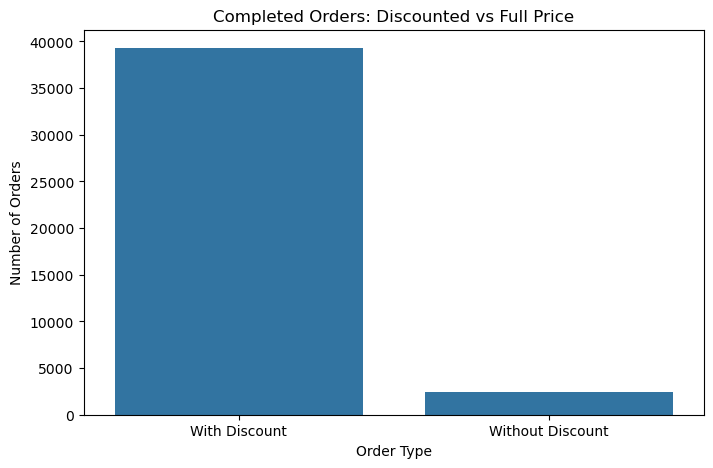

In [28]:
# Bar chart: orders with vs without discounts
data = pd.DataFrame({
    'Order Type': ['With Discount', 'Without Discount'],
    'Count': [orders_with_discount, orders_without_discount]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='Order Type', y='Count')
plt.title('Completed Orders: Discounted vs Full Price')
plt.ylabel('Number of Orders')
plt.show()

## Average Order Value: Discounted vs Full Price

In [26]:
# Calculate total revenue per order and whether it had any discount
order_stats = clean_orderlines.groupby('id_order').agg({
    'revenue': 'sum',
    'is_discounted': 'any'
})

# AOV for each group
aov_with_discount = order_stats[order_stats['is_discounted'] == True]['revenue'].mean()
aov_no_discount = order_stats[order_stats['is_discounted'] == False]['revenue'].mean()

difference = aov_with_discount - aov_no_discount
percentage_increase = (difference / aov_no_discount) * 100

print(f"AOV with discount:    €{aov_with_discount:.2f}")
print(f"AOV without discount: €{aov_no_discount:.2f}")
print(f"Difference:           €{difference:.2f} ({percentage_increase:.1f}% higher with discounts)")

AOV with discount:    €191.94
AOV without discount: €178.44
Difference:           €13.51 (7.6% higher with discounts)


Text(0.5, 1.0, 'Average Order Value: Discounted vs Full Price Orders')

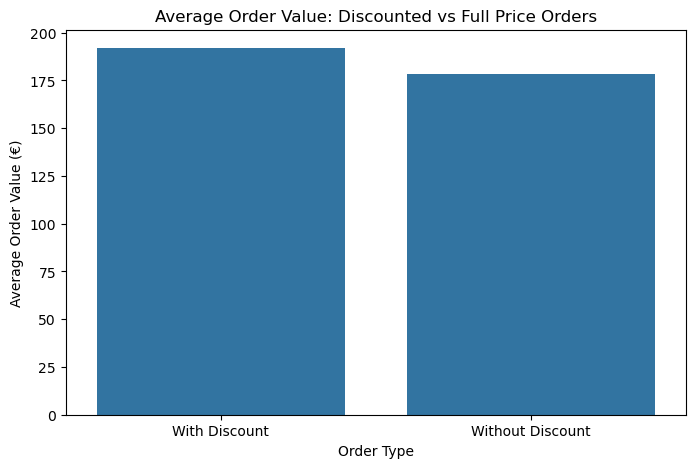

In [27]:
# Bar chart: AOV comparison
aov_data = pd.DataFrame({
    'Order Type': ['With Discount', 'Without Discount'],
    'Average Order Value (€)': [aov_with_discount, aov_no_discount]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=aov_data, x='Order Type', y='Average Order Value (€)')
plt.title('Average Order Value: Discounted vs Full Price Orders')

## Seasonality Analysis

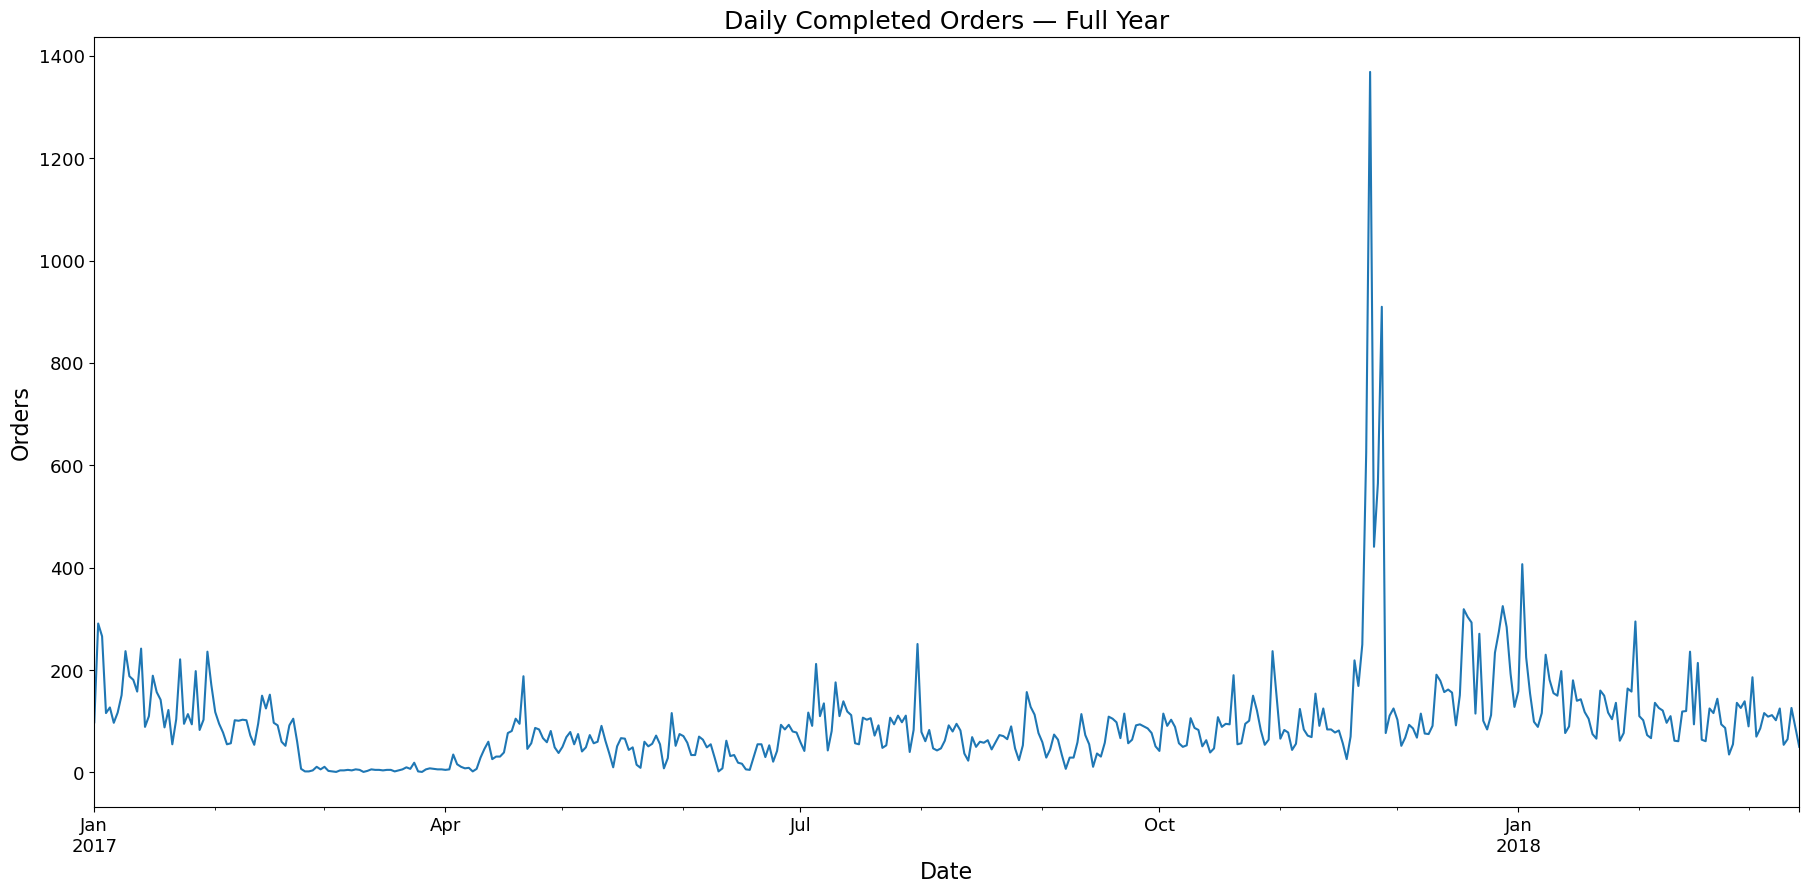

In [30]:
# Full year daily order volume

mask = clean_orders['state'] == 'Completed'
filtered_df = clean_orders[mask]

ax = (
    filtered_df
    .resample('D', on='created_date')
    ['order_id']
    .nunique()
    .plot(figsize=(22, 10))
)

plt.ylabel('Orders', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.tick_params(axis='both', labelsize=13)
plt.title('Daily Completed Orders — Full Year', fontsize=18)
plt.show()

## Seasonality — Black Friday Detail

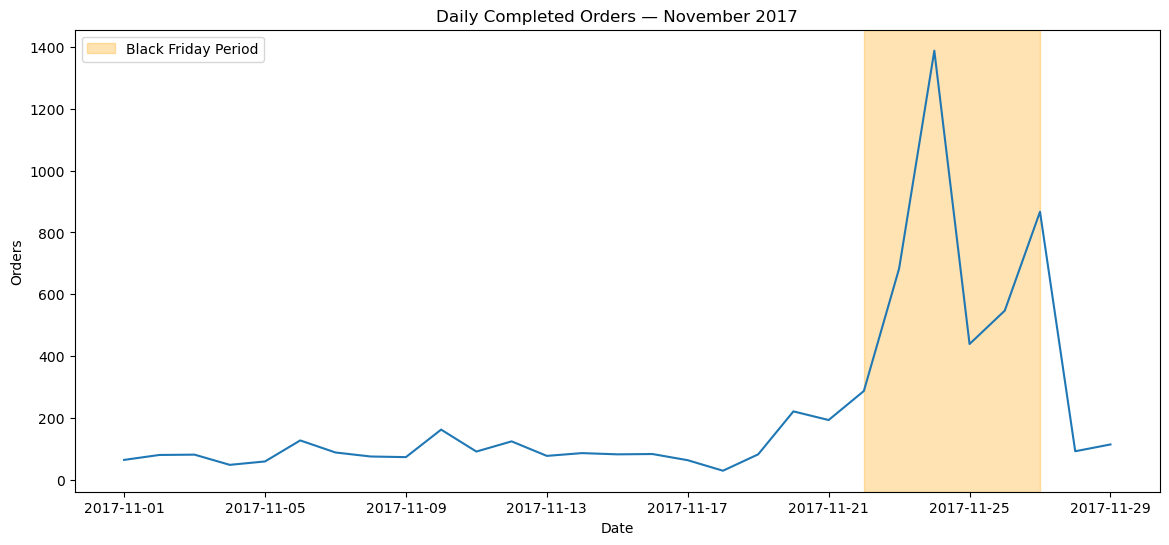

In [31]:
# November 2017 detail with Black Friday highlighted
mask = (
    (clean_orderlines['date'] >= '2017-11-01') &
    (clean_orderlines['date'] <= '2017-11-30')
)
november_data = clean_orderlines[mask]
daily_sales = november_data.resample('D', on='date')['id_order'].nunique().reset_index()
daily_sales.columns = ['date', 'orders']

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=daily_sales, x='date', y='orders', ax=ax)
ax.axvspan('2017-11-22', '2017-11-27', alpha=0.3, color='orange', label='Black Friday Period')
plt.title('Daily Completed Orders — November 2017')
plt.ylabel('Orders')
plt.xlabel('Date')
plt.legend()
plt.show()

In [32]:
# Black Friday stats
november = clean_orderlines[
    (clean_orderlines['date'] >= '2017-11-01') &
    (clean_orderlines['date'] <= '2017-11-30')
]

bf_mask = november['date'].between('2017-11-21', '2017-11-27')
bf_avg = november[bf_mask].groupby(november[bf_mask]['date'].dt.date)['id_order'].nunique().mean()
normal_avg = november[~bf_mask].groupby(november[~bf_mask]['date'].dt.date)['id_order'].nunique().mean()
bf_max = november[bf_mask].groupby(november[bf_mask]['date'].dt.date)['id_order'].nunique().max()
multiplier = bf_avg / normal_avg

print(f"Normal November daily average: {normal_avg:.0f} orders")
print(f"Black Friday week daily average: {bf_avg:.0f} orders")
print(f"Black Friday peak (single day): {bf_max:.0f} orders")
print(f"Multiplier: {multiplier:.2f}x")

Normal November daily average: 125 orders
Black Friday week daily average: 590 orders
Black Friday peak (single day): 1388 orders
Multiplier: 4.73x


## Revenue vs Potential Revenue. Erosion Chart

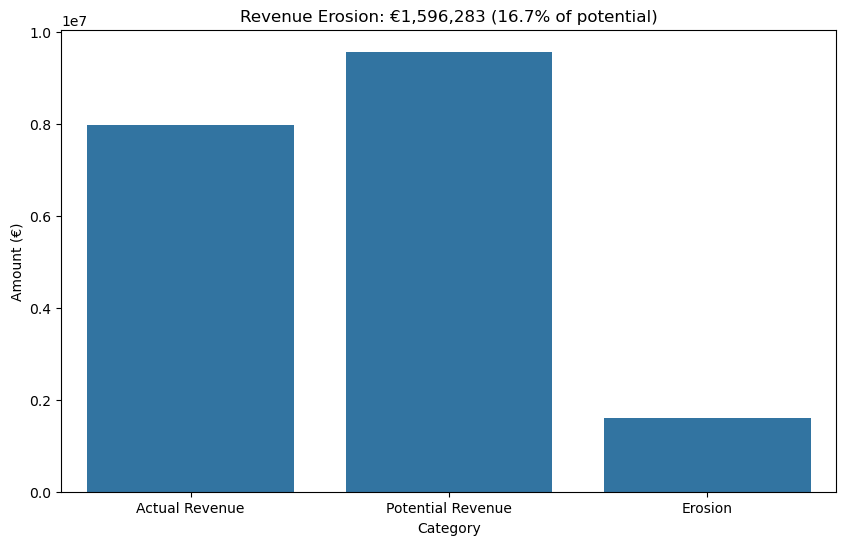

In [33]:
# Bar chart comparing actual vs potential revenue
revenue_data = pd.DataFrame({
    'Category': ['Actual Revenue', 'Potential Revenue', 'Erosion'],
    'Amount (€)': [actual_revenue, potential_revenue, erosion]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_data, x='Category', y='Amount (€)')
plt.title(f'Revenue Erosion: €{erosion:,.0f} ({erosion_percentage:.1f}% of potential)')
plt.ylabel('Amount (€)')
plt.show()